In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [ ]:
# 1. Download dataset

path = kagglehub.dataset_download("chaitanyagopidesi/smart-agriculture-dataset")
print("Dataset folder:", path)

# Show files inside the dataset directory
print("Files inside folder:")
print(os.listdir(path))

# 2. Load the CSV file
# Pick the first CSV automatically
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
file_path = os.path.join(path, csv_files[0])

print("\nUsing file:", file_path)
df = pd.read_csv(file_path)



Using Colab cache for faster access to the 'smart-agriculture-dataset' dataset.
Dataset folder: /kaggle/input/smart-agriculture-dataset
Files inside folder:
['cropdata_updated.csv']

Using file: /kaggle/input/smart-agriculture-dataset/cropdata_updated.csv


In [ ]:

def water_efficiency(MOI ,temp):
    if MOI  >3 and 20<= temp <=30 :
        return 2
    elif MOI  < 2 and temp >30 :
        return 0
    else:
        return 1

df['Water_Efficiency'] =df.apply(lambda row: water_efficiency(row['MOI'], row['temp']), axis=1)
def plant_stress(temp, humidity):
    if temp > 30 or humidity < 40:
        return 2
    elif temp > 25 or humidity < 50:
        return 1
    else:
        return 0

df['Plant_Stress'] = df.apply(lambda row: plant_stress(row['temp'], row['humidity']), axis=1)

df.rename(columns={"result": "Irrigation"}, inplace=True)
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
  crop ID   soil_type Seedling Stage  MOI  temp  humidity  Irrigation  \
0   Wheat  Black Soil    Germination    1    25      80.0           1   
1   Wheat  Black Soil    Germination    2    26      77.0           1   
2   Wheat  Black Soil    Germination    3    27      74.0           1   
3   Wheat  Black Soil    Germination    4    28      71.0           1   
4   Wheat  Black Soil    Germination    5    29      68.0           1   

   Water_Efficiency  Plant_Stress  
0                 1             0  
1                 1             1  
2                 1             1  
3                 2             1  
4                 2             1  


In [ ]:
print(df['Irrigation'].value_counts())
print(df['Water_Efficiency'].value_counts())
print(df['Plant_Stress'].value_counts())

Irrigation
0    9062
1    6227
2    1122
Name: count, dtype: int64
Water_Efficiency
1    11036
2     5311
0       64
Name: count, dtype: int64
Plant_Stress
2    7240
0    6789
1    2382
Name: count, dtype: int64


In [ ]:
df.isnull().sum()

,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
Irrigation,0
Water_Efficiency,0
Plant_Stress,0


In [ ]:
df.duplicated().sum()

np.int64(128)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:


# 3. Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

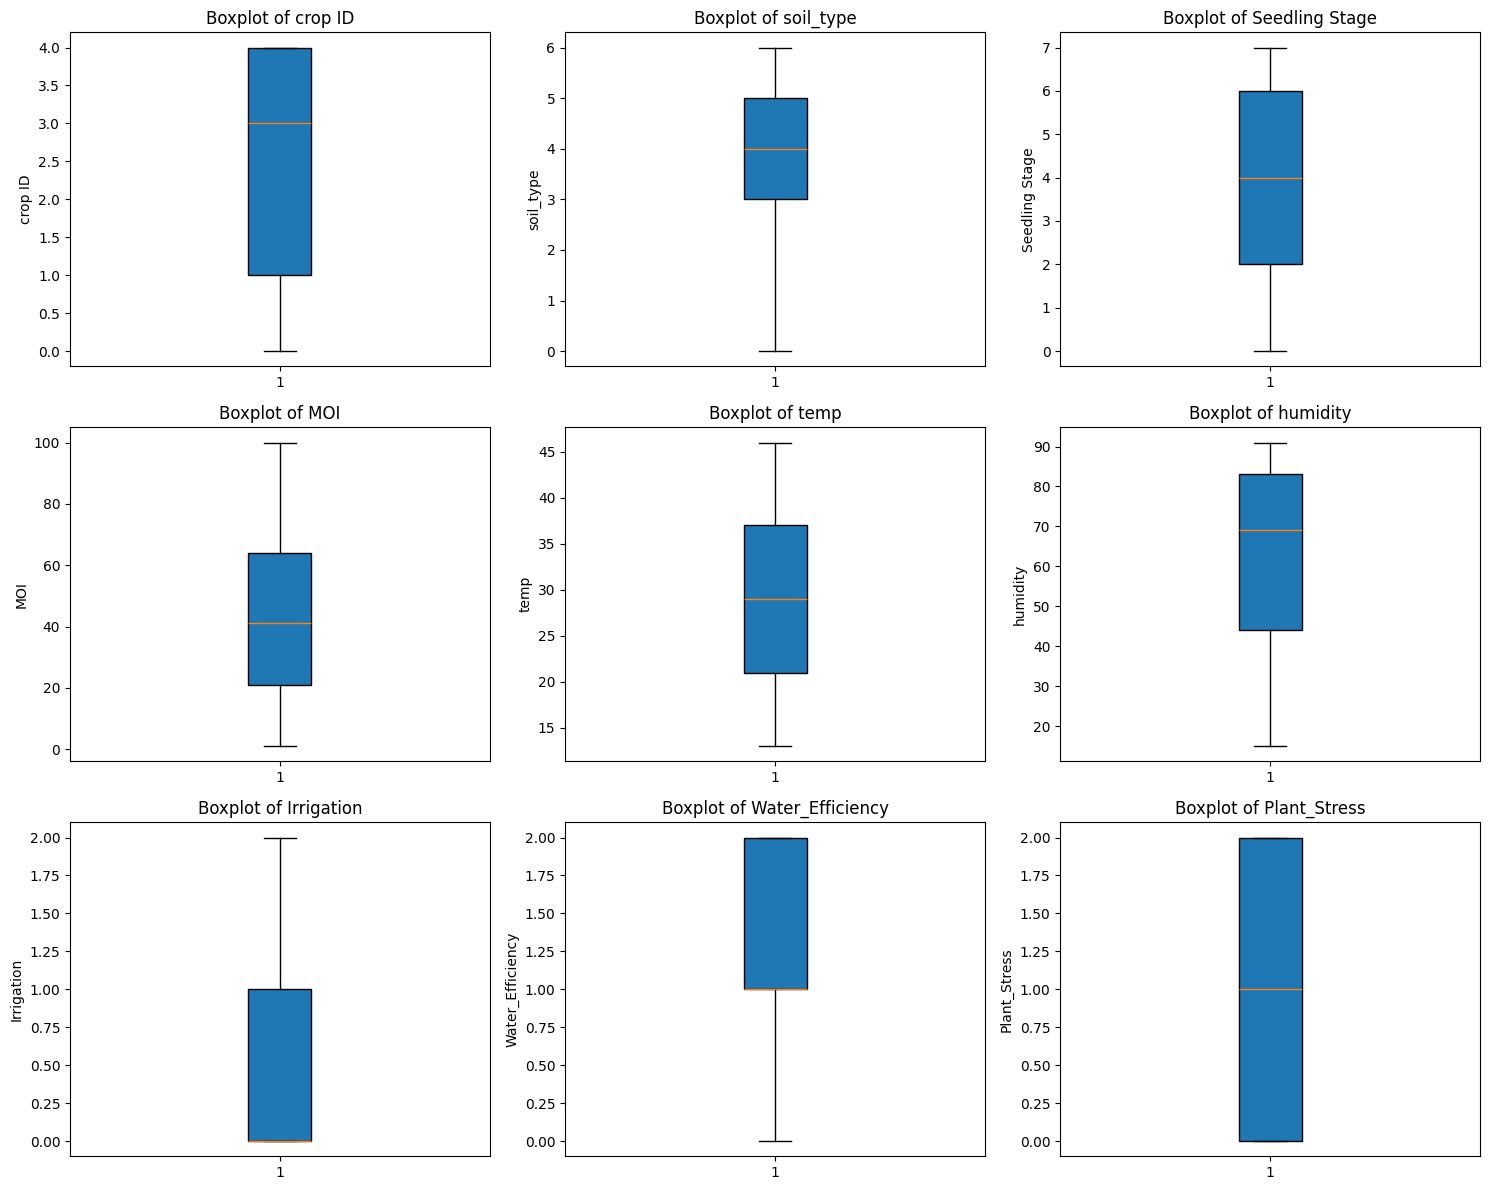

In [ ]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns


n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols*5, n_rows*4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col], vert=True, patch_artist=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

def detect_outliers_iqr(df):
    outlier_info = {}

    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR


        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_info[col] = {
            "count": len(outliers),
            "indices": outliers.index.tolist()
        }

    return outlier_info



outliers = detect_outliers_iqr(df)
outliers

{'crop ID': {'count': 0, 'indices': []},
 'soil_type': {'count': 0, 'indices': []},
 'Seedling Stage': {'count': 0, 'indices': []},
 'MOI': {'count': 0, 'indices': []},
 'temp': {'count': 0, 'indices': []},
 'humidity': {'count': 0, 'indices': []},
 'Irrigation': {'count': 0, 'indices': []},
 'Water_Efficiency': {'count': 0, 'indices': []},
 'Plant_Stress': {'count': 0, 'indices': []}}

In [ ]:
X = df[['crop ID', 'soil_type', 'Seedling Stage', 'MOI', 'temp', 'humidity']]
y = df[['Irrigation', 'Water_Efficiency', 'Plant_Stress']]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = MultiOutputClassifier(RandomForestClassifier(n_estimators=200, random_state=42))

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

for i, col in enumerate(y.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))




--- Irrigation ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2267
           1       0.98      1.00      0.99      1552
           2       0.92      0.84      0.88       252

    accuracy                           0.98      4071
   macro avg       0.97      0.94      0.95      4071
weighted avg       0.98      0.98      0.98      4071


--- Water_Efficiency ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00      2704
           2       1.00      1.00      1.00      1353

    accuracy                           1.00      4071
   macro avg       1.00      1.00      1.00      4071
weighted avg       1.00      1.00      1.00      4071


--- Plant_Stress ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1711
           1       1.00      1.00      1.00       589
       

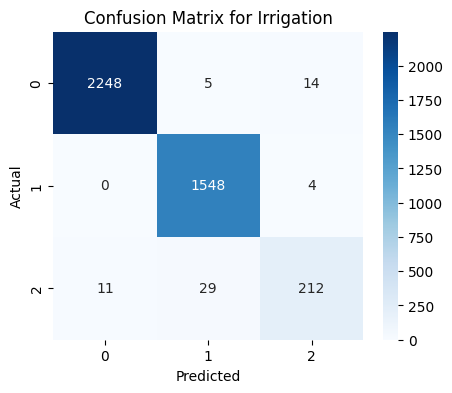

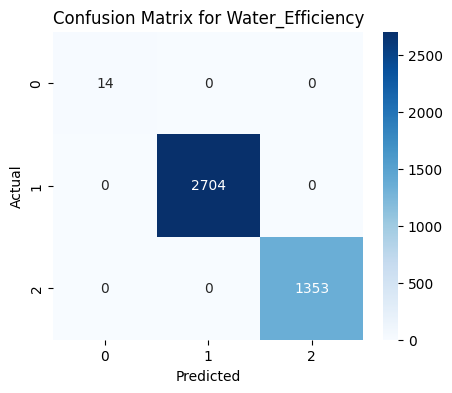

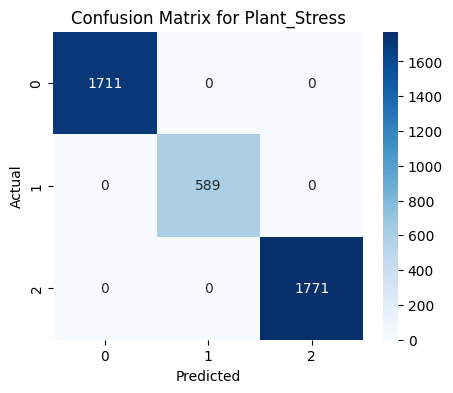

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



for i, target_name in enumerate(y.columns):
    cm = confusion_matrix(y_test.iloc[:, i], y_pred[:, i])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {target_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

--------------------------------------


Feature Importance for Irrigation:
  crop ID: 0.0337
  soil_type: 0.0259
  Seedling Stage: 0.0808
  MOI: 0.3646
  temp: 0.2813
  humidity: 0.2137


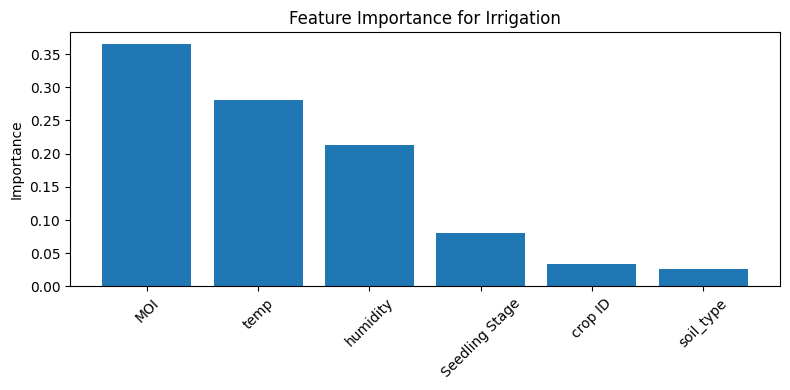


Feature Importance for Water_Efficiency:
  crop ID: 0.0010
  soil_type: 0.0007
  Seedling Stage: 0.0007
  MOI: 0.0687
  temp: 0.5039
  humidity: 0.4249


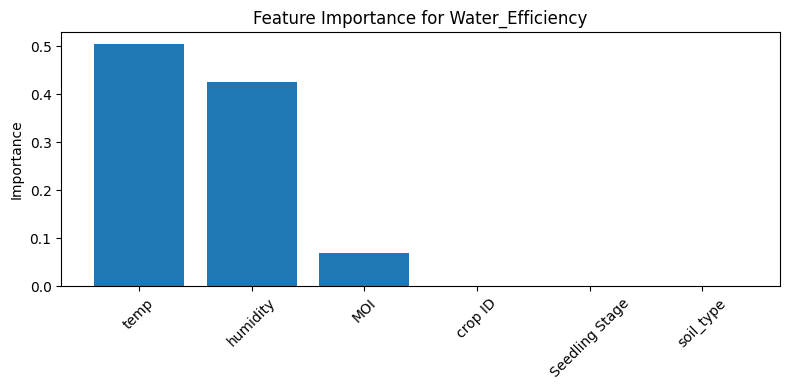


Feature Importance for Plant_Stress:
  crop ID: 0.0012
  soil_type: 0.0004
  Seedling Stage: 0.0006
  MOI: 0.0273
  temp: 0.5667
  humidity: 0.4038


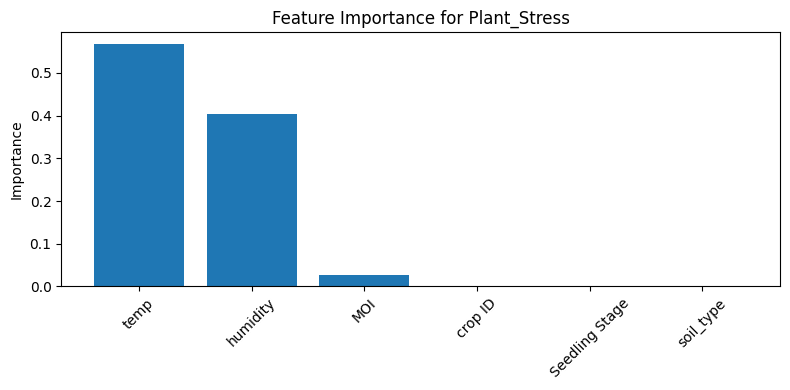

In [ ]:

for i, target_name in enumerate(y.columns):
    importances = model.estimators_[i].feature_importances_
    features = X.columns

    print(f"\nFeature Importance for {target_name}:")
    for f, imp in zip(features, importances):
        print(f"  {f}: {imp:.4f}")


    plt.figure(figsize=(8,4))
    indices = np.argsort(importances)[::-1]

    plt.title(f"Feature Importance for {target_name}")
    plt.bar(range(len(features)), importances[indices], align='center')
    plt.xticks(range(len(features)), features[indices], rotation=45)
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()